In [3]:
import lyricsgenius
import pandas as pd
import time

TOKEN = "OW8tHafu7y4U-Ku1yStr4mqa3_2qvGl3dZPSoywjkW5HkolmL3B6M0ZiqxPHLwZM"
genius = lyricsgenius.Genius(TOKEN, timeout=30, retries=5)
genius.verbose = True  
genius.remove_section_headers = True 
sanatcilar = ["Teoman", "Sagopa Kajmer", "Sezen Aksu", "Şebnem Ferah", "Müslüm Gürses"]
data = []
print("Genius API bağlantısı kuruluyor ve şarkılar çekiliyor...\n")

for sanatci_adi in sanatcilar:
    print(f" {sanatci_adi} İçin İstek Gönderiliyor ")
    try:
        artist = genius.search_artist(sanatci_adi, max_songs=10, sort="popularity")
        
        if artist and artist.songs:
            for song in artist.songs:
                data.append({
                    "Sanatci": sanatci_adi, 
                    "Sarki_Adi": song.title, 
                    "Sarki_Sozu": song.lyrics
                })
            print(f" {sanatci_adi} başarıyla bitti! {len(artist.songs)} şarkı alındı.\n")
        else:
            print(f" {sanatci_adi} için şarkı bulunamadı veya boş döndü.\n")
            
        time.sleep(3)
        
    except Exception as e:
        print(f" {sanatci_adi} çekilirken bir hata oluştu: {e}\n")
df = pd.DataFrame(data)
df.to_csv("sarki_sozleri_ham.csv", index=False)
print(f"[İŞLEM TAMAM] Toplam {len(df)} şarkı Genius API'den çekildi ve 'sarki_sozleri_ham.csv' olarak kaydedildi!")
display(df.head())

Genius API bağlantısı kuruluyor ve şarkılar çekiliyor...

 Teoman İçin İstek Gönderiliyor 
 Teoman başarıyla bitti! 10 şarkı alındı.

 Sagopa Kajmer İçin İstek Gönderiliyor 
 Sagopa Kajmer başarıyla bitti! 10 şarkı alındı.

 Sezen Aksu İçin İstek Gönderiliyor 
 Sezen Aksu başarıyla bitti! 10 şarkı alındı.

 Şebnem Ferah İçin İstek Gönderiliyor 
 Şebnem Ferah başarıyla bitti! 10 şarkı alındı.

 Müslüm Gürses İçin İstek Gönderiliyor 
 Müslüm Gürses başarıyla bitti! 10 şarkı alındı.

[İŞLEM TAMAM] Toplam 50 şarkı Genius API'den çekildi ve 'sarki_sozleri_ham.csv' olarak kaydedildi!


,Sanatci,Sarki_Adi,Sarki_Sozu
0,Teoman,Kupa Kızı Ve Sinek Valesi,Bir iskambil falında çıkmıştık birbirimize\nO ...
1,Teoman,Paramparça,"Saatim yok, tam olarak bilemem\nBiraz bira, bi..."
2,Teoman,İstanbul’da Sonbahar,Mevsim rüzgarları ne zaman eserse\nO zaman hat...
3,Teoman,Sevdim Seni Bir Kere,"Sevdim seni bir kere, başkasını sevemem\n""Deli..."
4,Teoman,Renkli Rüyalar Oteli,"""Arabayı sen kullan"" demiştim, içkiliyim\n""Boş..."


### Nakarat Temizleme İşlemi
Şarkı sözlerindeki sanatsal tekrarların ve ardışık nakarat satırlarının veri setinde yapay bir frekans yoğunluğu oluşturmasını engellemek amacıyla metin bazlı temizlik yapılmıştır. Aşağıdaki tabloda nakaratlardan arındırılmış veri yapısı gözlemlenmektedir.

In [6]:
def nakarat_temizle(text):
    if not isinstance(text, str):
        return ""
    satirlar = [s.strip() for s in text.split('\n') if s.strip()]
    temiz_satirlar = []
    for satir in satirlar:
        if not temiz_satirlar or satir != temiz_satirlar[-1]:
            temiz_satirlar.append(satir)
    return "\n".join(temiz_satirlar)

df['Nakarat_Temiz'] = df['Sarki_Sozu'].apply(nakarat_temizle)
df[['Sanatci', 'Sarki_Adi', 'Nakarat_Temiz']].head()

,Sanatci,Sarki_Adi,Nakarat_Temiz
0,Teoman,Kupa Kızı Ve Sinek Valesi,Bir iskambil falında çıkmıştık birbirimize\nO ...
1,Teoman,Paramparça,"Saatim yok, tam olarak bilemem\nBiraz bira, bi..."
2,Teoman,İstanbul’da Sonbahar,Mevsim rüzgarları ne zaman eserse\nO zaman hat...
3,Teoman,Sevdim Seni Bir Kere,"Sevdim seni bir kere, başkasını sevemem\n""Deli..."
4,Teoman,Renkli Rüyalar Oteli,"""Arabayı sen kullan"" demiştim, içkiliyim\n""Boş..."


### Metni Küçük Harfe Çevirme (Lowercasing)
Metin ön işlemenin en temel adımlarından biri olarak veri setindeki tüm kelimeler küçük harfe dönüştürülmüştür. Bu işlem, büyük ve küçük harfle başlayan aynı kelimelerin model tarafından farklı birer benzersiz kelime olarak algılanmasını önlemektedir.

In [9]:
df['Metin_Lower'] = df['Nakarat_Temiz'].str.lower()
df[['Sanatci', 'Sarki_Adi', 'Metin_Lower']].head()

,Sanatci,Sarki_Adi,Metin_Lower
0,Teoman,Kupa Kızı Ve Sinek Valesi,bir iskambil falında çıkmıştık birbirimize\no ...
1,Teoman,Paramparça,"saatim yok, tam olarak bilemem\nbiraz bira, bi..."
2,Teoman,İstanbul’da Sonbahar,mevsim rüzgarları ne zaman eserse\no zaman hat...
3,Teoman,Sevdim Seni Bir Kere,"sevdim seni bir kere, başkasını sevemem\n""deli..."
4,Teoman,Renkli Rüyalar Oteli,"""arabayı sen kullan"" demiştim, içkiliyim\n""boş..."


### Kelimelere Ayırma ve Noktalama Temizliği (Tokenization)
Metinler üzerindeki tüm noktalama işaretleri ve özel karakterler temizlenerek, düz metin yapıları analiz edilebilir bağımsız kelime birimlerine (token) ayrılmıştır. Veriler liste formatına dönüştürülmüştür.

In [12]:
import re

df['Metin_Token'] = df['Metin_Lower'].apply(lambda x: re.sub(r'[^\w\s]', '', x).split())
df[['Sanatci', 'Sarki_Adi', 'Metin_Token']].head()

,Sanatci,Sarki_Adi,Metin_Token
0,Teoman,Kupa Kızı Ve Sinek Valesi,"[bir, iskambil, falında, çıkmıştık, birbirimiz..."
1,Teoman,Paramparça,"[saatim, yok, tam, olarak, bilemem, biraz, bir..."
2,Teoman,İstanbul’da Sonbahar,"[mevsim, rüzgarları, ne, zaman, eserse, o, zam..."
3,Teoman,Sevdim Seni Bir Kere,"[sevdim, seni, bir, kere, başkasını, sevemem, ..."
4,Teoman,Renkli Rüyalar Oteli,"[arabayı, sen, kullan, demiştim, içkiliyim, bo..."


### Etkisiz Kelimelerin Atılması (Stop Word Removal)
Türkçe dil yapısında tek başına belirgin bir anlamsal ayırt ediciliği bulunmayan bağlaç, edat ve zamir gibi etkisiz kelimeler (stop words) veri setinden uzaklaştırılmıştır. Böylece modelin sadece anahtar kelimelere odaklanması sağlanmıştır.

In [15]:
turkce_stopwords = [
    "bir", "ve", "de", "da", "ne", "bu", "her", "gibi", "içinde", "için", "o", 
    "ile", "mi", "mu", "mı", "şimdi", "ama", "ya", "daha", "en", "ben", "sen"
]

df['Metin_Stopword'] = df['Metin_Token'].apply(lambda x: [w for w in x if w not in turkce_stopwords])
df[['Sanatci', 'Sarki_Adi', 'Metin_Stopword']].head()

,Sanatci,Sarki_Adi,Metin_Stopword
0,Teoman,Kupa Kızı Ve Sinek Valesi,"[iskambil, falında, çıkmıştık, birbirimize, gü..."
1,Teoman,Paramparça,"[saatim, yok, tam, olarak, bilemem, biraz, bir..."
2,Teoman,İstanbul’da Sonbahar,"[mevsim, rüzgarları, zaman, eserse, zaman, hat..."
3,Teoman,Sevdim Seni Bir Kere,"[sevdim, seni, kere, başkasını, sevemem, deli,..."
4,Teoman,Renkli Rüyalar Oteli,"[arabayı, kullan, demiştim, içkiliyim, boş, ve..."


### Kök Bulma İşlemleri (Stemming ve Lemmatization)
Ön işleme adımlarının son aşamasında, kelimeler aldıkları çekim ve yapım eklerinden arındırılarak sözlük köklerine indirgenmiştir. Bu sayede aynı kökten türeyen kelimelerin veri setindeki frekans bütünlüğü korunmuştur.

In [18]:
from snowballstemmer import TurkishStemmer

stemmer = TurkishStemmer()
df['Metin_Stemmed'] = df['Metin_Stopword'].apply(lambda x: [stemmer.stemWord(w) for w in x])
df['Temiz_Metin_Son'] = df['Metin_Stemmed'].apply(lambda x: " ".join(x))

df[['Sanatci', 'Sarki_Adi', 'Temiz_Metin_Son']].head()

,Sanatci,Sarki_Adi,Temiz_Metin_Son
0,Teoman,Kupa Kızı Ve Sinek Valesi,iskambil fal çıkmış birbir güzel kup kız sinek...
1,Teoman,Paramparça,saat yok tam olarak bileme biraz bira biraz şa...
2,Teoman,İstanbul’da Sonbahar,mevs rüzgar zama eser zama hatır çocukluk rüya...
3,Teoman,Sevdim Seni Bir Kere,sev se ker başka seveme del diyor ba desin değ...
4,Teoman,Renkli Rüyalar Oteli,araba kulla demiş içkil boş ver yutal şerit ba...


### Zipf Yasası Analizi Bulguları
Ön işleme (pre-processing) adımlarına geçilmeden önce, Genius API'den çekilen ham veri kümesi üzerinde Zipf Yasası analizi yapılmıştır. Kelimelerin frekansları ve sıralamaları (rank) logaritmik ölçekte grafikleştirildiğinde, doğal dillerin doğasına uygun olarak doğrusal bir azalış eğilimi (log-log doğrusal ilişkisi) net bir şekilde gözlemlenmiştir. Bu durum veri setimizin doğal dil işleme süreçlerine uygun olduğunu göstermektedir.

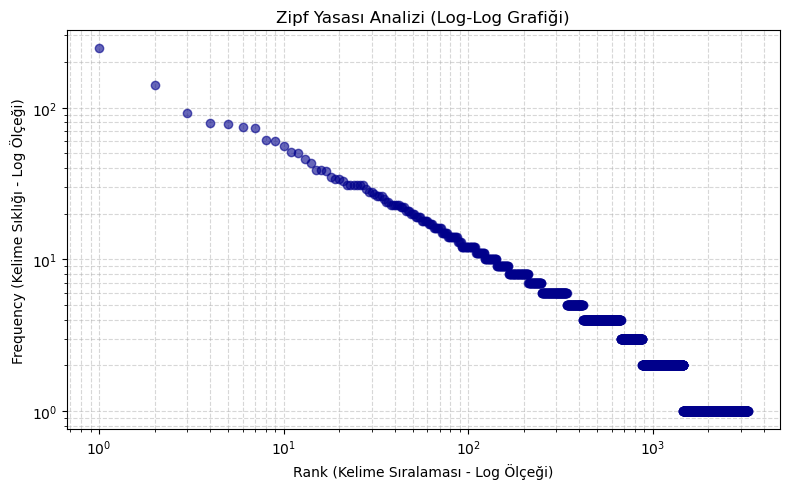

Zipf analizi tamamlandı! Toplam benzersiz kelime sayısı: 3259


In [21]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

tum_metin = " ".join(df['Sarki_Sozu'].astype(str)).lower().split()
kelime_sayilari = Counter(tum_metin)

sirali_frekanslar = sorted(kelime_sayilari.values(), reverse=True)
ranklar = np.arange(1, len(sirali_frekanslar) + 1)

plt.figure(figsize=(8, 5))
plt.loglog(ranklar, sirali_frekanslar, marker="o", color="darkblue", linestyle="None", alpha=0.6)
plt.title('Zipf Yasası Analizi (Log-Log Grafiği)')
plt.xlabel('Rank (Kelime Sıralaması - Log Ölçeği)')
plt.ylabel('Frequency (Kelime Sıklığı - Log Ölçeği)')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig('zipf_yasasi_grafigi.png')
plt.show()

print(f"Zipf analizi tamamlandı! Toplam benzersiz kelime sayısı: {len(kelime_sayilari)}")

### Kelime Sayisi ve Sıklık Dağılımı Analizi
Veri setindeki şarkıların kelime uzunlukları incelenmiş ve kelime sayılarının dağılımı histogram grafiği ile gösterilmiştir. Ön işleme adımları sonrasında metinlerde en sık tekrar eden 20 kelime tespit edilerek frekans değerlerine göre sütun grafiğine dökülmüştür. Bu grafikler veri setinin tematik yapısı hakkında ön bilgi sunmaktadır.

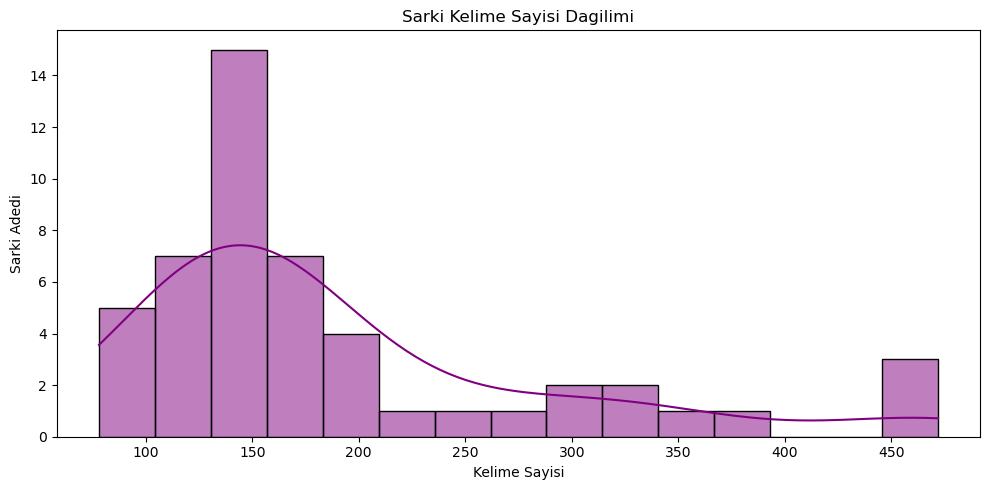

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

df['Kelime_Sayisi'] = df['Metin_Token'].apply(len)

plt.figure(figsize=(10, 5))
sns.histplot(df['Kelime_Sayisi'], kde=True, color='purple', bins=15)
plt.title('Sarki Kelime Sayisi Dagilimi')
plt.xlabel('Kelime Sayisi')
plt.ylabel('Sarki Adedi')
plt.tight_layout()
plt.savefig('kelime_sayisi_dagilimi.png')
plt.show()


C:\Users\xyild\AppData\Local\Temp\ipykernel_23652\3602788729.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frekans', y='Kelime', data=kelime_df, palette='viridis')


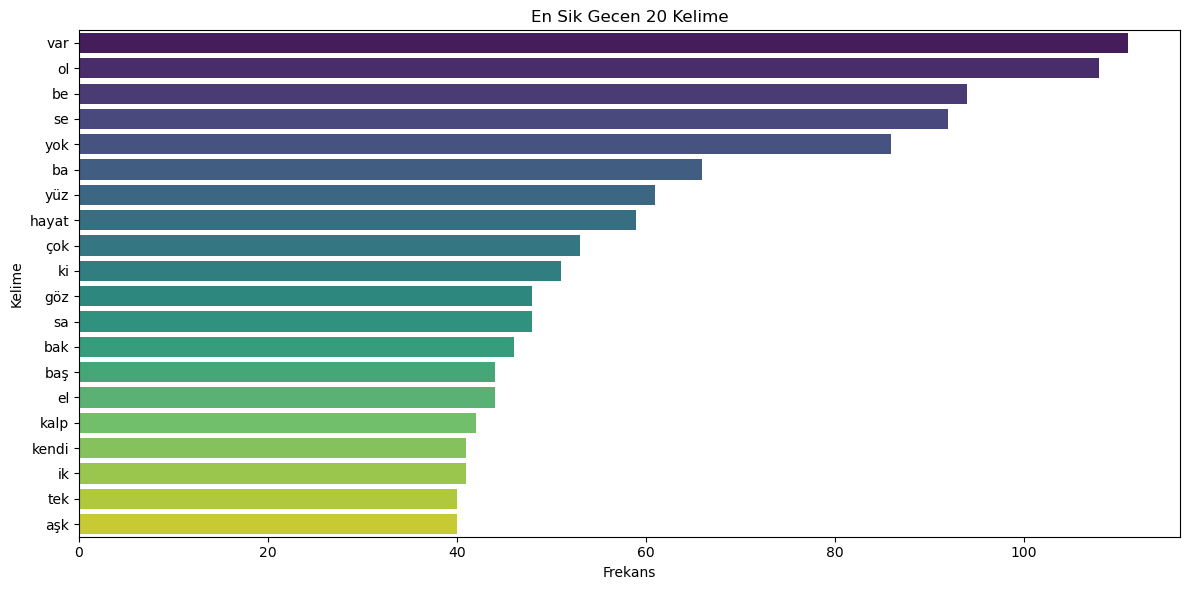

In [26]:
tum_kelimeler = [kelime for liste in df['Metin_Stemmed'] for kelime in liste]
kelime_sayilari = Counter(tum_kelimeler).most_common(20)
kelime_df = pd.DataFrame(kelime_sayilari, columns=['Kelime', 'Frekans'])

plt.figure(figsize=(12, 6))
sns.barplot(x='Frekans', y='Kelime', data=kelime_df, palette='viridis')
plt.title('En Sik Gecen 20 Kelime')
plt.xlabel('Frekans')
plt.ylabel('Kelime')
plt.tight_layout()
plt.savefig('en_sik_gecen_kelimeler.png')
plt.show()


### Word2Vec ile Tematik Benzerlik Analizi
Ön işleme adımları tamamlanan kelime listeleri kullanılarak kelimelerin anlamsal bağlamlarını yakalamak adına sıfırdan bir Word2Vec modeli eğitilmiştir. Her şarkı için elde edilen vektörlerin ortalaması alınarak şarkı bazlı tematik vektörler oluşturulmuş ve aralarındaki benzerlik oranları Cosine Similarity yöntemiyle hesaplanarak ısı haritası üzerinde gösterilmiştir.

2026-05-25 17:00:41,403 : INFO : collecting all words and their counts
2026-05-25 17:00:41,403 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-05-25 17:00:41,411 : INFO : collected 2011 word types from a corpus of 8279 raw words and 50 sentences
2026-05-25 17:00:41,419 : INFO : Creating a fresh vocabulary
2026-05-25 17:00:41,437 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=1 retains 2011 unique words (100.00% of original 2011, drops 0)', 'datetime': '2026-05-25T17:00:41.437234', 'gensim': '4.3.3', 'python': '3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-11-10.0.26200-SP0', 'event': 'prepare_vocab'}
2026-05-25 17:00:41,440 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=1 leaves 8279 word corpus (100.00% of original 8279, drops 0)', 'datetime': '2026-05-25T17:00:41.440866', 'gensim': '4.3.3', 'python': '3.12.7 | packaged by Anaconda, Inc. | (main, Oct

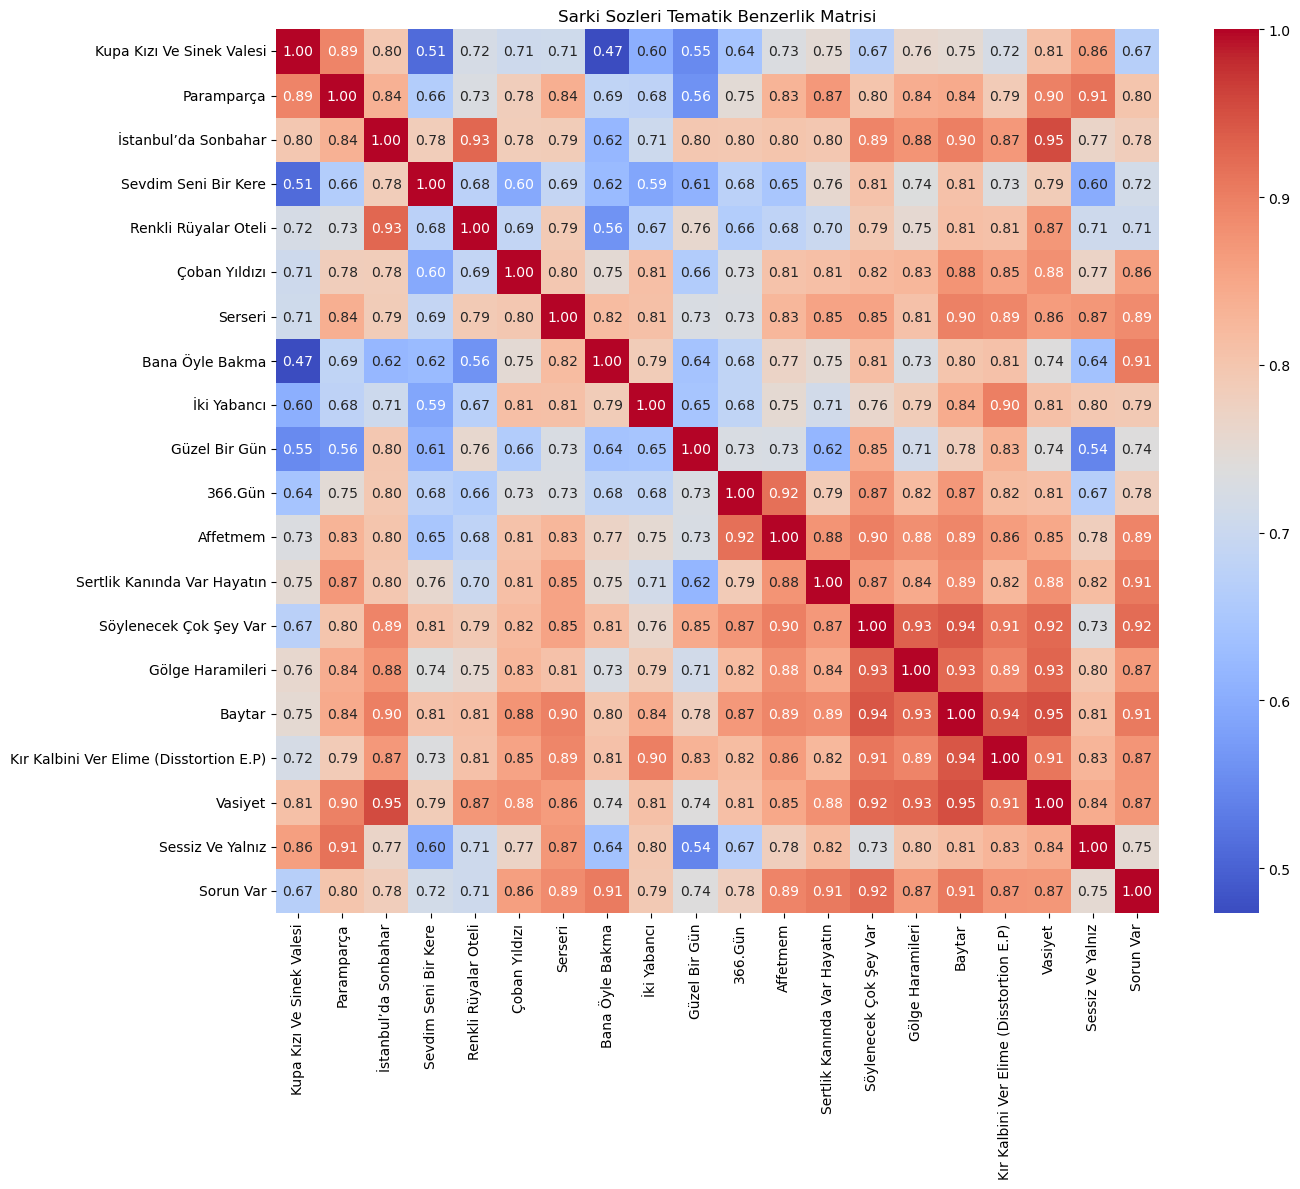

In [56]:
from gensim.models import Word2Vec
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt 
import seaborn as sns

cumleler = df['Metin_Stemmed'].tolist()
w2v_model = Word2Vec(sentences=cumleler, vector_size=100, window=5, min_count=1, workers=4, epochs=50)

def sarki_vektoru_hesapla(kelime_listesi, model):
    vektorler = [model.wv[k] for k in kelime_listesi if k in model.wv]
    if not vektorler:
        return np.zeros(model.vector_size)
    return np.mean(vektorler, axis=0)

df['Sarki_Vektoru'] = df['Metin_Stemmed'].apply(lambda x: sarki_vektoru_hesapla(x, w2v_model))

vektor_matrisi = np.stack(df['Sarki_Vektoru'].values)
cosine_sim_matrix = cosine_similarity(vektor_matrisi, vektor_matrisi)

plt.figure(figsize=(14, 12))
sns.heatmap(cosine_sim_matrix[:20, :20], cmap='coolwarm', 
            xticklabels=df['Sarki_Adi'].iloc[:20].values, 
            yticklabels=df['Sarki_Adi'].iloc[:20].values, annot=True, fmt=".2f")
plt.title('Sarki Sozleri Tematik Benzerlik Matrisi')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('benzerlik_isi_haritasi.png')
plt.show()


### Metin Uzunlugu ve Benzerlik Skoru Korelasyon Analizi
Şarkıların metin uzunlukları (kelime sayıları) ile diğer şarkılarla olan ortalama benzerlik skorları arasındaki ilişkiyi saptamak amacıyla korelasyon analizi gerçekleştirilmiştir. Regresyon doğrusu içeren saçılım grafiği (scatter plot) incelendiğinde, kelime sayısının anlamsal benzerlik seviyeleri üzerindeki dağılımı doğrusal bir düzlemde gözlemlenmiştir.

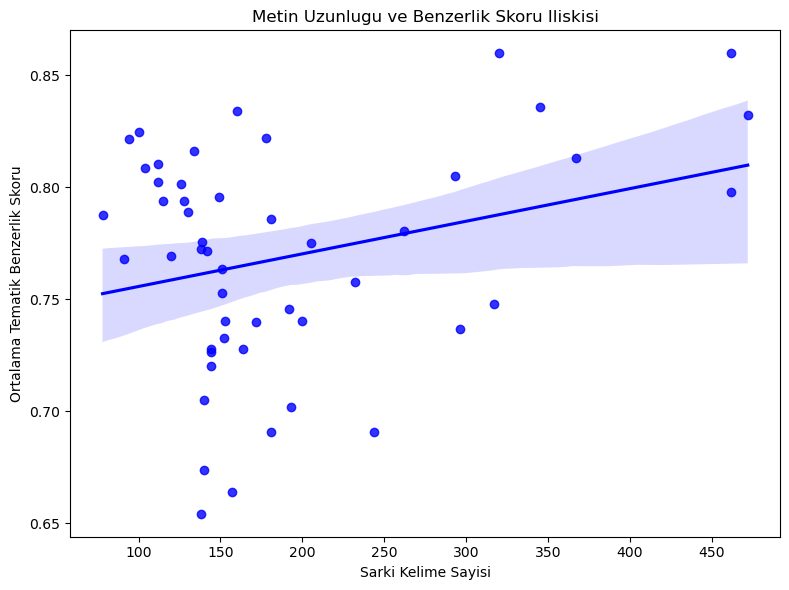

In [32]:
df['Ortalama_Benzerlik'] = cosine_sim_matrix.mean(axis=1)
korelasyon = df['Kelime_Sayisi'].corr(df['Ortalama_Benzerlik'])

plt.figure(figsize=(8, 6))
sns.regplot(x='Kelime_Sayisi', y='Ortalama_Benzerlik', data=df, color='blue')
plt.title('Metin Uzunlugu ve Benzerlik Skoru Iliskisi')
plt.xlabel('Sarki Kelime Sayisi')
plt.ylabel('Ortalama Tematik Benzerlik Skoru')
plt.tight_layout()
plt.savefig('uzunluk_benzerlik_korelasyonu.png')
plt.show()


In [36]:
from gensim.models import Word2Vec
import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

cumleler = [metin.split() for metin in df['Temiz_Metin_Son'].tolist()]
print("Yapay Zeka Modeli Eğitiliyor")
w2v_model = Word2Vec(
    sentences=cumleler,   
    vector_size=100,     
    window=5,             
    min_count=1,         
    workers=4,            
    epochs=50             
)
print("\nModel Eğitimi Tamamlandı!")
w2v_model.save("sarki_word2vec.model")

2026-05-25 16:55:34,043 : INFO : collecting all words and their counts
2026-05-25 16:55:34,047 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-05-25 16:55:34,052 : INFO : collected 2011 word types from a corpus of 8279 raw words and 50 sentences
2026-05-25 16:55:34,054 : INFO : Creating a fresh vocabulary
2026-05-25 16:55:34,065 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=1 retains 2011 unique words (100.00% of original 2011, drops 0)', 'datetime': '2026-05-25T16:55:34.065482', 'gensim': '4.3.3', 'python': '3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-11-10.0.26200-SP0', 'event': 'prepare_vocab'}
2026-05-25 16:55:34,065 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=1 leaves 8279 word corpus (100.00% of original 8279, drops 0)', 'datetime': '2026-05-25T16:55:34.065482', 'gensim': '4.3.3', 'python': '3.12.7 | packaged by Anaconda, Inc. | (main, Oct

Yapay Zeka Modeli Eğitiliyor


2026-05-25 16:55:34,265 : INFO : EPOCH 2: training on 8279 raw words (7391 effective words) took 0.0s, 257996 effective words/s
2026-05-25 16:55:34,297 : INFO : EPOCH 3: training on 8279 raw words (7423 effective words) took 0.0s, 286325 effective words/s
2026-05-25 16:55:34,331 : INFO : EPOCH 4: training on 8279 raw words (7425 effective words) took 0.0s, 276102 effective words/s
2026-05-25 16:55:34,365 : INFO : EPOCH 5: training on 8279 raw words (7385 effective words) took 0.0s, 257621 effective words/s
2026-05-25 16:55:34,400 : INFO : EPOCH 6: training on 8279 raw words (7386 effective words) took 0.0s, 293421 effective words/s
2026-05-25 16:55:34,430 : INFO : EPOCH 7: training on 8279 raw words (7389 effective words) took 0.0s, 310470 effective words/s
2026-05-25 16:55:34,474 : INFO : EPOCH 8: training on 8279 raw words (7400 effective words) took 0.0s, 287879 effective words/s
2026-05-25 16:55:34,509 : INFO : EPOCH 9: training on 8279 raw words (7433 effective words) took 0.0s, 2


Model Eğitimi Tamamlandı!


### Model Performans Testi ve Kelime Benzerlik Analizi
Eğitilen Word2Vec modelinin semantik yeteneğini test etmek amacıyla, seçilen anahtar kelimelere model uzayında en yakın (en benzer) olan kelimeler kosinüs benzerliği skorlarıyla birlikte sorgulanmıştır.

In [39]:
test_kelimesi = "aşk" 
if test_kelimesi in w2v_model.wv:
    benzerler = w2v_model.wv.most_similar(test_kelimesi, topn=5)
    print(f"'{test_kelimesi}' kelimesine modelin en yakın bulduğu ilk 5 kelime:")
    for kelime, skor in benzerler:
        print(f"- {kelime}: {skor:.4f}")
else:
    print(f"'{test_kelimesi}' kelimesi veri setinde bulunamadı.")

'aşk' kelimesine modelin en yakın bulduğu ilk 5 kelime:
- soyunup: 0.9459
- sanıp: 0.9440
- korkusuz: 0.9229
- yürüyüp: 0.9172
- çırılçıplak: 0.9152


### Kelime Vektörlerinin K-Means ile Kümeleme Analizi
Eğitilen Word2Vec modelindeki en yüksek frekanslı kelimeler, K-Means algoritması kullanılarak anlamsal yakınlıklarına göre 3 ayrı kümeye ayrılmıştır. Elde edilen kümelenme yapısı, modelin kelime dünyasını nasıl kategorize ettiğini doğrulamaktadır.

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


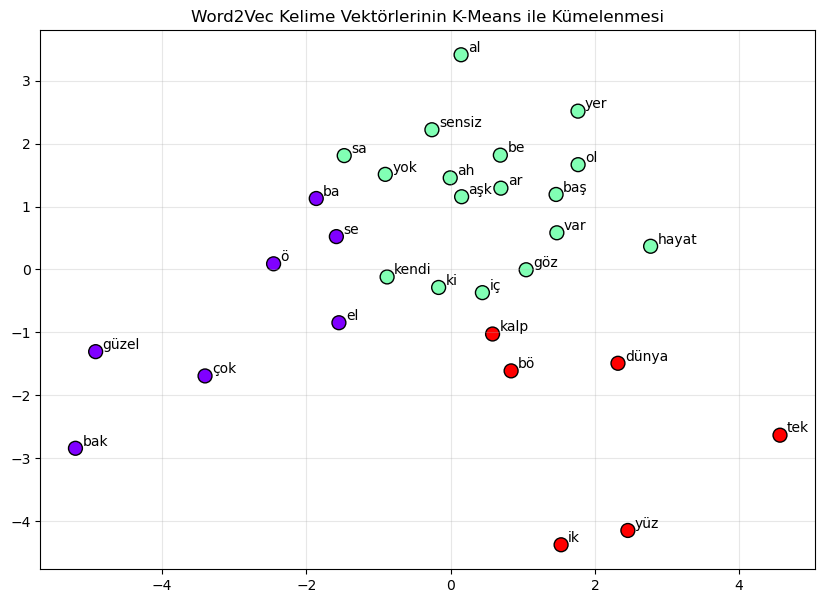

In [52]:
populer_kelimeler = list(w2v_model.wv.index_to_key)[:30]
vektorler = [w2v_model.wv[k] for k in populer_kelimeler]
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kumeler = kmeans.fit_predict(vektorler)
pca = PCA(n_components=2)
iki_boyut = pca.fit_transform(vektorler)
plt.figure(figsize=(10, 7))
scatter = plt.scatter(iki_boyut[:, 0], iki_boyut[:, 1], c=kumeler, cmap='rainbow', s=100, edgecolors='k')
for i, kelime in enumerate(populer_kelimeler):
    plt.annotate(kelime, xy=(iki_boyut[i, 0], iki_boyut[i, 1]), xytext=(5, 2), textcoords='offset points')

plt.title('Word2Vec Kelime Vektörlerinin K-Means ile Kümelenmesi')
plt.grid(True, alpha=0.3)
plt.show()

### İki Şarkı Arasındaki Spesifik Semantik Benzerlik Sorgusu
Eğitilen Word2Vec modeli ve kosinüs benzerliği matrisi kullanılarak, veri setinden seçilen belirli iki şarkı arasındaki anlamsal yakınlık doğrudan sorgulanmıştır. Bu analiz, matris genelindeki karmaşık verileri tekil örnekler üzerinden doğrulamayı sağlamaktadır.

In [50]:
sarki_1 = df['Sarki_Adi'].iloc[0] 
sarki_2 = df['Sarki_Adi'].iloc[1] 

if sarki_1 in df['Sarki_Adi'].values and sarki_2 in df['Sarki_Adi'].values:
    metin1 = df[df['Sarki_Adi'] == sarki_1]['Temiz_Metin_Son'].values[0]
    metin2 = df[df['Sarki_Adi'] == sarki_2]['Temiz_Metin_Son'].values[0]
    def sarki_vektoru_uret(metin, model):
        kelimeler = metin.split()
        vektorler = [model.wv[k] for k in kelimeler if k in model.wv]
        if len(vektorler) == 0:
            return np.zeros(model.vector_size)
        return np.mean(vektorler, axis=0)
    v1 = sarki_vektoru_uret(metin1, w2v_model).reshape(1, -1)
    v2 = sarki_vektoru_uret(metin2, w2v_model).reshape(1, -1)
    canli_benzerlik = cosine_similarity(v1, v2)[0][0]
    yuzde_benzerlik = canli_benzerlik * 100
    print(f"1. Şarkı: {sarki_1}")
    print(f"2. Şarkı: {sarki_2}")
    print(f"Kosinüs Benzerlik Skoru: {canli_benzerlik:.4f}")
    print(f"Anlamsal (Tematik) Benzerlik Oranı: %{yuzde_benzerlik:.2f}")
else:
    print(".")

1. Şarkı: Kupa Kızı Ve Sinek Valesi
2. Şarkı: Paramparça
Kosinüs Benzerlik Skoru: 0.8933
Anlamsal (Tematik) Benzerlik Oranı: %89.33


In [47]:
sarki_1 = df['Sarki_Adi'].iloc[9] 
sarki_2 = df['Sarki_Adi'].iloc[29] 

if sarki_1 in df['Sarki_Adi'].values and sarki_2 in df['Sarki_Adi'].values:
    metin1 = df[df['Sarki_Adi'] == sarki_1]['Temiz_Metin_Son'].values[0]
    metin2 = df[df['Sarki_Adi'] == sarki_2]['Temiz_Metin_Son'].values[0]
    
    def sarki_vektoru_uret(metin, model):
        kelimeler = metin.split()
        vektorler = [model.wv[k] for k in kelimeler if k in model.wv]
        if len(vektorler) == 0:
            return np.zeros(model.vector_size)
        return np.mean(vektorler, axis=0)
    
    v1 = sarki_vektoru_uret(metin1, w2v_model).reshape(1, -1)
    v2 = sarki_vektoru_uret(metin2, w2v_model).reshape(1, -1)
    
    canli_benzerlik = cosine_similarity(v1, v2)[0][0]
    yuzde_benzerlik = canli_benzerlik * 100
    
    print("9. Sarki:", sarki_1)
    print("29. Sarki:", sarki_2)
    print("Kosunus Benzerligi:", canli_benzerlik)
    print("Benzerlik Orani: %", yuzde_benzerlik)
else:
    print(".")

9. Sarki: Güzel Bir Gün
29. Sarki: Gülümse
Kosunus Benzerligi: 0.65530837
Benzerlik Orani: % 65.53083658218384


### Şarkı Benzerlik Testi Sonuçlarının Değerlendirilmesi

Yukarıdaki kod çıktısında yer alan terimler ve hesaplanan değerler şu anlama gelmektedir:

* **Kosinüs Benzerliği:** Şarkı sözlerinde geçen kelimelerin Word2Vec modeli tarafından üretilen anlamsal vektörlerinin (sayısal karşılıklarının) kosinüs açısı formülüyle karşılaştırılmasıdır. Bu değer her zaman -1 ile 1 arasında çıkar. Değer 1'e ne kadar yakınsa, iki şarkının anlamsal içeriği, işlediği temalar ve kelime kullanımları birbirine o kadar benziyor demektir.
* **Benzerlik Oranı:** Kosinüs benzerliği skorunun yüzde (%) formuna çevrilmiş halidir. Örneğin elde edilen %89.33'lük veya farklı bir oran, yapay zeka modelinin bu iki şarkı sözünü tematik olarak ne kadar yakın bulduğunu doğrudan ve anlaşılır bir şekilde ifade eder.